# Byzatine Resilient Zero Order Optimization for Scalable Fedarated Fine Tuning of Large Language Models - Paper Implementation

Tasks:
1. Running FEDByZO algorithm
2. validate the model on clean data
3. inject Byzantine attacks
4. comparing the results

## Task 1 — Running FEDBYZO Algorithm
Problem setup and key idea
- **Problem:** Fedarated Learning with high communication cost, Byzantine clients, and zero‑order (ZO) gradients.
- **Key ideas:**
  - work in **perturbation space** with shared seeds.
  - Estimate the gradient with two point zero order estimate rather than explicit calculation
  - Clients send only $\nu$ scalars, not full vectors to fedarator.
  - **Robust aggregation:** coordinate‑wise trimmed mean removes outliers (assumes $b < n/2$).
- **Tested Attack :** label flipping on Byzantine clients.


-**FedAvg** (baseline)

-**FEDBYZO** (ZO + trimmed mean)

In [8]:
import math
import random
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(7)  # Results  will vary between runs without it
random.seed(7)
device = torch.device("cpu")

# Demo Parameters Assumption ---
n_clients = 10
byz_ratio = 0.3  # fraction of Byzantine clients for attack experiments
local_steps = 2
rounds = 12
batch_size = 64
nu = 6
mu = 1e-3
eta = 0.05
lr = 0.1  # client step size for FedAvg
trim_ratio = 0.3  # trimmed mean ratio (assumes < 30% Byzantine)
base_seed = 12345

In [9]:
transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_subset = Subset(train_ds, list(range(6000)))
test_subset = Subset(test_ds, list(range(1000)))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)  # global train loader (optional)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

all_indices = list(range(len(train_subset)))
random.shuffle(all_indices)
split_size = len(all_indices) // n_clients
client_indices = [all_indices[i * split_size:(i + 1) * split_size] for i in range(n_clients)]

clients_data = []
for idxs in client_indices:  # build each client's local dataset
    xs = torch.stack([train_subset[i][0].view(-1) for i in idxs]).to(device)
    ys = torch.tensor([train_subset[i][1] for i in idxs], device=device)
    clients_data.append((xs, ys))

## Required Functions
utilities

ZO estimator

shared seed directions

Trimmed mean aggregation.

In [10]:
def build_model():  # tiny logistic regression model
    model = nn.Linear(28 * 28, 10, bias=True).to(device)
    return model

def vectorize(model):
    return torch.nn.utils.parameters_to_vector(model.parameters()).detach().clone()

def devectorize(model, vec):
    torch.nn.utils.vector_to_parameters(vec, model.parameters())

def accuracy(model, loader):  # compute accuracy on loader
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.view(x.size(0), -1).to(device)
            y = y.to(device)
            logits = model(x)  # forward pass
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.numel()
    return correct / max(total, 1)

def get_batch(x, y, batch_size):
    idx = torch.randint(0, x.size(0), (batch_size,))
    return x[idx], y[idx]

def generate_direction(d, t, l, r, base_seed):  # shared‑seed direction
    seed = base_seed + t * 100000 + l * 1000 + r
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)
    z = torch.randn(d, generator=gen, device=device)
    z = z / (torch.norm(z) + 1e-12)
    return z

def trimmed_mean(G, trim_ratio):  # coordinate‑wise trimmed mean
    n = G.size(0)
    h = int(n * trim_ratio)
    sorted_G, _ = torch.sort(G, dim=0)
    trimmed = sorted_G[h:n - h, :]
    return trimmed.mean(dim=0)

def zo_scalar_two_point(model, x, y, z, mu):
    w = vectorize(model)
    devectorize(model, w + mu * z)
    loss_plus = nn.CrossEntropyLoss()(model(x), y)
    devectorize(model, w - mu * z)
    loss_minus = nn.CrossEntropyLoss()(model(x), y)  # loss at w-mu z
    devectorize(model, w)
    d = w.numel()
    g_hat = d * (loss_plus - loss_minus) / (2 * mu)
    return g_hat.detach()

def maybe_flip_labels(y, is_byzantine):  # Byzantine attck - Lable Flipping
    if not is_byzantine:
        return y
    return 9 - y

## Implemented FedAvg (baseline)
first‑order baseline before any Byzantine attacks.

In [11]:
class Client:  # client with local data and optional Byzantine behavior
    def __init__(self, x, y, is_byzantine=False):  # initialize client
        self.x = x
        self.y = y
        self.is_byzantine = is_byzantine

    def local_sgd(self, model, steps, lr, batch_size): # FedAvg local training
        model = build_model() if model is None else model # ensure a model exists
        model.train()
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # SGD optimizer
        for _ in range(steps):
            xb, yb = get_batch(self.x, self.y, batch_size)
            yb = maybe_flip_labels(yb, self.is_byzantine)  # optional attack
            optimizer.zero_grad()
            loss = nn.CrossEntropyLoss()(model(xb), yb)  # compute loss
            loss.backward()  # Compute Gradients
            optimizer.step() #Update Model Weights
        return vectorize(model)  # return updated parameters

    def local_zo(self, model, t, steps, nu, mu, batch_size, base_seed):  # # FEDBYZO local ZO scalars
        model.train()
        g_list = []
        for l in range(steps):
            xb, yb = get_batch(self.x, self.y, batch_size)
            yb = maybe_flip_labels(yb, self.is_byzantine)  # Label Flip if Byzantine
            g_step = []
            for r in range(nu):
                z = generate_direction(vectorize(model).numel(), t, l, r, base_seed)
                g_hat = zo_scalar_two_point(model, xb, yb, z, mu)
                g_step.append(g_hat)
            g_list.append(torch.stack(g_step))
        return torch.stack(g_list)

class Server:
    def __init__(self, clients):
        self.clients = clients
        self.model = build_model()

    def fedavg_round(self, steps, lr, batch_size):  # FedAvg round
        new_vectors = []
        for c in self.clients:
            local_model = build_model()
            devectorize(local_model, vectorize(self.model))  # sync params over local copy of model
            new_vec = c.local_sgd(local_model, steps, lr, batch_size)  #Train model
            new_vectors.append(new_vec)
        avg_vec = torch.mean(torch.stack(new_vectors), dim=0)
        devectorize(self.model, avg_vec)  # update global with avg

    def fedbyzo_round(self, t, steps, nu, mu, eta, batch_size, base_seed, trim_ratio):  # run FEDBYZO
        G_all = []
        for c in self.clients:
            g_steps = c.local_zo(self.model, t, steps, nu, mu, batch_size, base_seed)
            g_flat = g_steps.mean(dim=0)
            G_all.append(g_flat)
        G = torch.stack(G_all, dim=0)
        R = trimmed_mean(G, trim_ratio)  # robust aggregate
        d = vectorize(self.model).numel()
        Z_cols = []
        for r in range(nu):
            z = generate_direction(d, t, 0, r, base_seed)
            Z_cols.append(z)
        Z = torch.stack(Z_cols, dim=1)
        w = vectorize(self.model)
        w = w - eta * (Z @ R) / nu  # update in perturbation space
        devectorize(self.model, w)

## TASK 2: validate the model on clean data
Ran both methods without Byzantine clients to validate the core algorithm.

In [12]:
def run_experiment(byz_ratio, method):
    n_byz = int(n_clients * byz_ratio)  # number of Byzantine clients
    clients = []
    for i in range(n_clients):
        is_byz = i < n_byz  # mark Byzantine
        x_i, y_i = clients_data[i]
        clients.append(Client(x_i, y_i, is_byzantine=is_byz))
    server = Server(clients)
    acc_trace = []  # track accuracy

    for t in range(rounds):  # Over global Epochs
        if method == "fedavg":
            server.fedavg_round(local_steps, lr, batch_size)
        elif method == "fedbyzo":
            server.fedbyzo_round(t, local_steps, nu, mu, eta, batch_size, base_seed, trim_ratio)
        else:
            raise ValueError("Unknown method")
        acc = accuracy(server.model, test_loader)
        acc_trace.append(acc)

    d = vectorize(server.model).numel()
    comm_fedavg = d  # scalars per client in a epoch for FedAvg
    comm_fedbyzo = nu  # lly for FEDBYZO
    return acc_trace, (comm_fedavg if method == "fedavg" else comm_fedbyzo)

results_clean = {}

for method in ["fedavg", "fedbyzo"]:
    acc_trace, comm = run_experiment(0.0, method)  # run with no attack
    results_clean[method] = {"acc": acc_trace, "comm": comm}

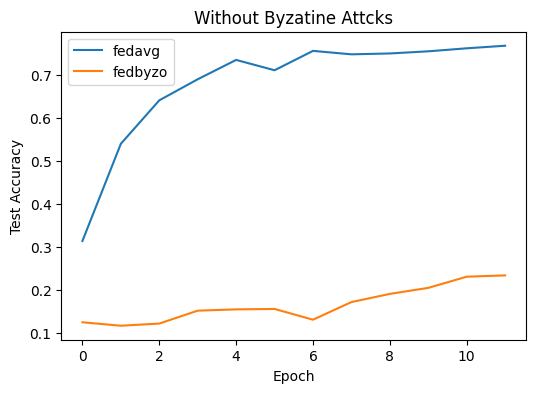

In [13]:
plt.figure(figsize=(6, 4))
for key, val in results_clean.items():
    plt.plot(val["acc"], label=key)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Without Byzatine Attcks")
plt.legend()
plt.show()

## Task 3 : inject Byzantine attacks label flipping
Enabled label flipping of some clients and re ran.

In [14]:
results_attack = {}

for method in ["fedavg", "fedbyzo"]:
    acc_trace, comm = run_experiment(byz_ratio, method)  # run with attack
    results_attack[method] = {"acc": acc_trace, "comm": comm}

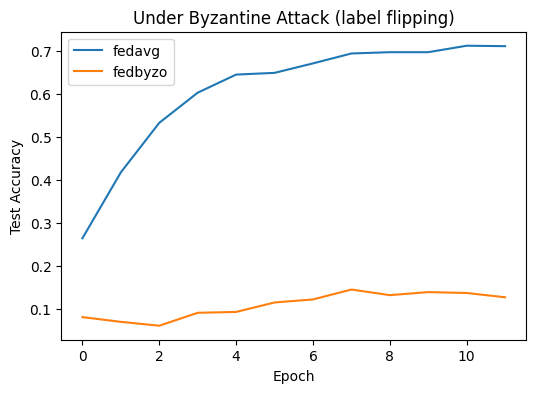

In [15]:
plt.figure(figsize=(6, 4))
for key, val in results_attack.items():
    plt.plot(val["acc"], label=key)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Under Byzantine Attack (label flipping)")
plt.legend()
plt.show()

## Task 4— Final comparison and communication cost
comparing clean vs attack and highlighting communication savings.

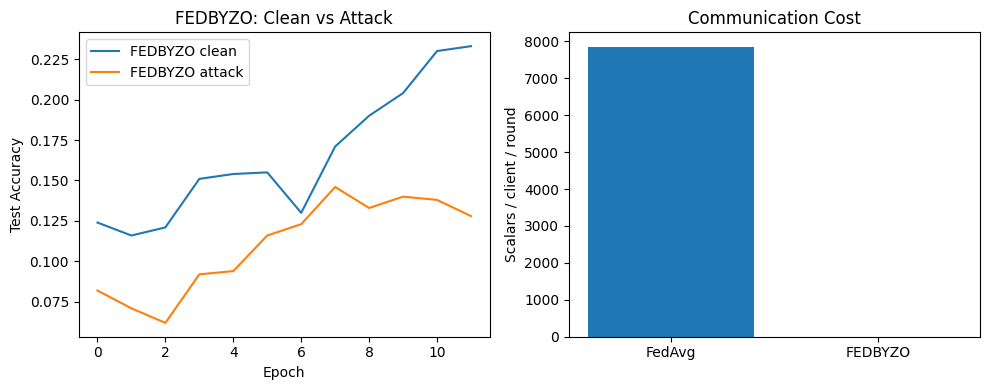

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(results_clean["fedbyzo"]["acc"], label="FEDBYZO clean")
plt.plot(results_attack["fedbyzo"]["acc"], label="FEDBYZO attack")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("FEDBYZO: Clean vs Attack")
plt.legend()

plt.subplot(1, 2, 2)
labels = ["FedAvg", "FEDBYZO"]
comm_vals = [results_clean["fedavg"]["comm"], results_clean["fedbyzo"]["comm"]]
plt.bar(labels, comm_vals)
plt.ylabel("Scalars / client / round")
plt.title("Communication Cost")

plt.tight_layout()
plt.show()

## Notes (ideas, assumptions, trade offs)
- **Why perturbation space?** Only $\nu$ scalars per client per round, not $d$‑dimensional gradients/weights.
- **Robust aggregation:** trimmed mean is order‑optimal under Byzantine workers when $b < n/2$.
- **Attacks:** label flipping is a simple but strong data‑poisoning baseline.
- **Trade‑off:** higher $\nu$ → lower variance but more communication.
- **Trade‑off:** $\mu$ too small → noisy estimates; too large → biased estimates.
- **Expectation:** FedAvg degrades under attack; FEDBYZO remains more stable.

